# Part 2 : La Régression Logistique

**Durée estimée : 2h**

## 🎯 Objectifs d'apprentissage

À la fin de cette partie, vous serez capable de :
1. **Expliquer** pourquoi la régression linéaire ne fonctionne pas pour la classification
2. **Décrire** comment la fonction sigmoid transforme un score en probabilité
3. **Appliquer** la régression logistique avec scikit-learn
4. **Ajuster** le seuil de décision selon le contexte business

---

## 🌍 Problème Réel : Comment Gmail sait-il que ce message est un spam ?

Chaque jour, votre boîte email reçoit des dizaines de messages. Certains arrivent dans votre boîte de réception, d'autres sont automatiquement envoyés dans les **spams**.

**Question :** Comment Gmail (ou Outlook) peut-il décider en une fraction de seconde si un email est légitime ou spam ?

*(Prenez 30 secondes pour réfléchir...)*

<details>
<summary>🤔 Votre intuition ?</summary>

### 🔑 Réponse

Gmail analyse des **caractéristiques** de l'email :
- Contient-il des mots suspects ("gratuit", "gagnez", "urgent") ?
- L'expéditeur est-il dans vos contacts ?
- Y a-t-il beaucoup de liens ?
- Le format ressemble-t-il à un spam connu ?

Ensuite, un modèle de **classification** prédit : **Spam** ou **Non-spam**.

C'est exactement ce que fait la **régression logistique** : prédire une catégorie (et non un nombre comme la régression linéaire).

</details>

### La détection de spam : un cas d'étude réel

Selon une [étude IEEE 2024](https://ieeexplore.ieee.org/abstract/document/11013300/), la régression logistique avec TF-IDF (une technique de traitement de texte) peut identifier des mots-clés critiques comme **"pill"**, **"PHP"** et **"Businessweek"** qui indiquent un pattern de spam.

Une autre [étude 2024](https://link.springer.com/article/10.1007/s10207-023-00756-1) utilisant un ensemble de modèles avec régression logistique comme méta-classifieur a atteint **98.8% de précision** sur la détection de spam.

| Caractéristique de l'email | Indice de spam |
|---------------------------|----------------|
| Contient "FREE" en majuscules | Fort |
| Beaucoup de points d'exclamation | Fort |
| Expéditeur inconnu | Moyen |
| Lien vers un domaine suspect | Fort |
| Adresse dans les contacts | Faible |

---

## 2.1 De la Régression à la Classification

### Le problème avec la régression linéaire

Dans la Part 1, nous avons utilisé la régression linéaire pour prédire un **prix** — un nombre continu qui peut prendre n'importe quelle valeur (150 000€, 237 500€, etc.).

Mais ici, notre problème est différent. On veut prédire : **Spam ou Non-spam**. C'est une **catégorie**, pas un nombre.

**Question :** Pourquoi ne pas simplement coder Non-spam = 0 et Spam = 1, puis utiliser la régression linéaire ?

*(Prenez 30 secondes pour y réfléchir... Qu'est-ce qui pourrait mal se passer ?)*

Essayons justement cette approche "naïve" et voyons ce qui se passe :

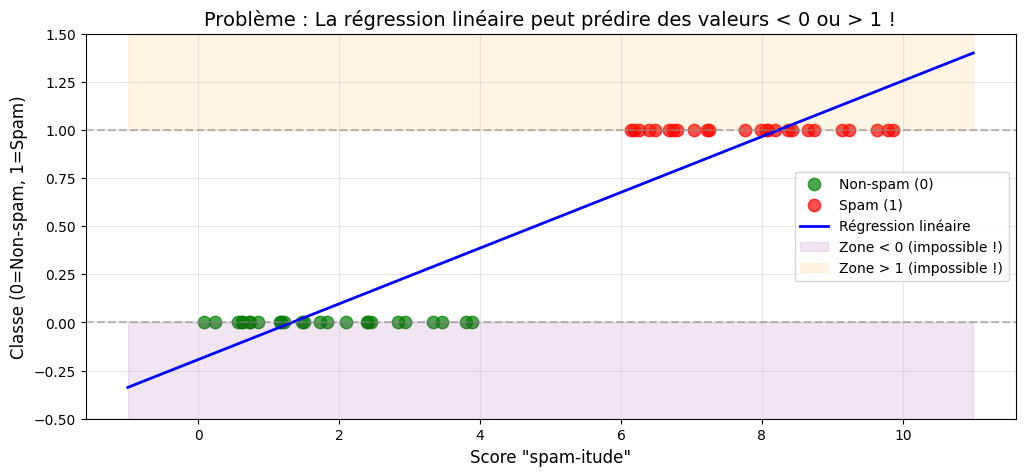


⚠️ Prédiction pour score = -1 : -0.34
⚠️ Prédiction pour score = 12 : 1.54

Ces valeurs n'ont pas de sens comme probabilités !


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression

# Données simplifiées : score de "spam-itude" d'un email
# Plus le score est élevé, plus l'email ressemble à un spam
np.random.seed(42)

# Générer des données
n_emails = 50
score_spam = np.concatenate([
    np.random.uniform(0, 4, 25),    # Non-spams (scores bas)
    np.random.uniform(6, 10, 25)    # Spams (scores élevés)
])
est_spam = np.concatenate([np.zeros(25), np.ones(25)])  # 0 = non-spam, 1 = spam

# Essayer la régression linéaire
model_lineaire = LinearRegression()
model_lineaire.fit(score_spam.reshape(-1, 1), est_spam)

# Prédictions
x_line = np.linspace(-1, 11, 100)
y_pred_lineaire = model_lineaire.predict(x_line.reshape(-1, 1))

# Visualisation
plt.figure(figsize=(12, 5))
plt.scatter(score_spam[est_spam==0], est_spam[est_spam==0], 
            c='green', s=80, label='Non-spam (0)', alpha=0.7)
plt.scatter(score_spam[est_spam==1], est_spam[est_spam==1], 
            c='red', s=80, label='Spam (1)', alpha=0.7)
plt.plot(x_line, y_pred_lineaire, 'b-', linewidth=2, label='Régression linéaire')

# Zones problématiques
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
plt.fill_between(x_line, -0.5, 0, alpha=0.1, color='purple', label='Zone < 0 (impossible !)')
plt.fill_between(x_line, 1, 1.5, alpha=0.1, color='orange', label='Zone > 1 (impossible !)')

plt.xlabel('Score "spam-itude"', fontsize=12)
plt.ylabel('Classe (0=Non-spam, 1=Spam)', fontsize=12)
plt.title('Problème : La régression linéaire peut prédire des valeurs < 0 ou > 1 !', fontsize=14)
plt.legend(loc='center right')
plt.ylim(-0.5, 1.5)
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n⚠️ Prédiction pour score = -1 : {model_lineaire.predict([[-1]])[0]:.2f}")
print(f"⚠️ Prédiction pour score = 12 : {model_lineaire.predict([[12]])[0]:.2f}")
print("\nCes valeurs n'ont pas de sens comme probabilités !")

### Analysons ce graphique ensemble

Prenons le temps de comprendre ce que nous voyons :

**Les données (points) :**
- **Points verts (en bas)** : Ce sont les 25 emails Non-spam. On leur a attribué la valeur 0 (axe Y).
- **Points rouges (en haut)** : Ce sont les 25 emails Spam. On leur a attribué la valeur 1 (axe Y).
- **L'axe X** représente un "score de spam-itude" — plus le score est élevé, plus l'email a des caractéristiques de spam (mots suspects, liens douteux, etc.).

**La ligne bleue — que représente-t-elle ?**

C'est la droite que la régression linéaire a apprise. Elle essaie de "passer au milieu" des données pour faire des prédictions. Quand on lui donne un nouveau score, elle suit cette droite pour prédire une valeur.

**Le problème — regardez attentivement les zones colorées :**

| Zone | Couleur | Score X | Valeur Y prédite | Problème |
|------|---------|---------|------------------|----------|
| Gauche du graphique | Violette | Score négatif ou très bas | **< 0** | Probabilité négative ?! |
| Droite du graphique | Orange | Score très élevé (> 10) | **> 1** | Plus de 100% de probabilité ?! |

**Question :** Si le modèle prédit **-0.15** pour un email avec un score de -1, que signifie cette valeur ?

*(Réponse attendue : Rien du tout ! On ne peut pas avoir une probabilité de -15%. C'est mathématiquement impossible.)*

**Question :** Et si le modèle prédit **1.23** pour un email très suspect (score = 12) ?

*(Réponse attendue : Une probabilité de 123% n'existe pas. On ne peut pas être "plus que certain" — le maximum est 100%.)*

C'est le cœur du problème : **la régression linéaire trace une droite sans aucune contrainte**. Elle continue infiniment dans les deux directions, produisant des valeurs impossibles à interpréter comme des probabilités.

### Le besoin d'une nouvelle approche

<details>
<summary>🤔 Question Socratique : De quoi aurions-nous besoin pour résoudre ce problème ?</summary>

### 🔑 Réponse

On veut que notre modèle nous donne la **probabilité** qu'un email soit un spam.

Or, une probabilité a des règles strictes :
- Elle doit être **≥ 0** (on ne peut pas avoir moins de 0% de chance)
- Elle doit être **≤ 1** (on ne peut pas avoir plus de 100% de chance)

Il nous faut donc une fonction mathématique qui :
1. Prend le résultat de la régression linéaire (n'importe quel nombre)
2. Le transforme en une valeur **garantie** entre 0 et 1

Cette fonction existe, et elle s'appelle la **fonction sigmoid**.

</details>

### Récapitulatif du problème

```
┌─────────────────────────────────────────────────────────────────────┐
│ POURQUOI LA RÉGRESSION LINÉAIRE NE MARCHE PAS POUR LA CLASSIFICATION│
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   Régression linéaire : y = wx + b                                 │
│                                                                     │
│   ✗ Peut prédire -0.15  →  Probabilité négative ? IMPOSSIBLE       │
│   ✗ Peut prédire 1.23   →  Plus de 100% ? IMPOSSIBLE               │
│   ✗ Aucune contrainte sur la sortie                                │
│                                                                     │
│   BESOIN : Une fonction qui "écrase" tout vers [0, 1]              │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

---

## 2.2 La Fonction Sigmoid : Transformer un Score en Probabilité

### Construisons l'intuition avant la formule

Nous avons besoin d'une fonction qui prend n'importe quel nombre (la sortie de notre régression linéaire) et le transforme en une probabilité entre 0 et 1.

**Question :** Si vous deviez inventer cette fonction, quelles propriétés devrait-elle avoir ?

*(Prenez un moment pour y réfléchir...)*

<details>
<summary>🔑 Propriétés nécessaires</summary>

Notre fonction magique doit :
1. **Toujours retourner une valeur ≥ 0** (pas de probabilités négatives)
2. **Toujours retourner une valeur ≤ 1** (pas de probabilités > 100%)
3. **Retourner ~0.5 quand l'entrée est 0** (cas neutre = incertain)
4. **Retourner ~0 quand l'entrée est très négative** (forte certitude "Non")
5. **Retourner ~1 quand l'entrée est très positive** (forte certitude "Oui")

</details>

Cette fonction existe ! Elle s'appelle la **fonction sigmoid** (ou fonction logistique).

### À quoi ressemble cette fonction ?

Avant de voir la formule mathématique, visualisons son comportement. La sigmoid agit comme un "thermostat" qui compresse toutes les valeurs vers l'intervalle [0, 1] :

| Si l'entrée est... | La sigmoid retourne... | Interprétation |
|--------------------|------------------------|----------------|
| Très négative (-10, -5...) | Proche de 0 | "Très probablement NON" |
| Autour de 0 | Environ 0.5 | "Je ne sais pas, 50/50" |
| Très positive (+5, +10...) | Proche de 1 | "Très probablement OUI" |

**Question :** Si vous deviez dessiner cette fonction sur un graphique, quelle forme aurait-elle ?

*(Réponse attendue : Une courbe en forme de S — plate en bas à gauche, qui monte rapidement au milieu, puis plate en haut à droite)*

Vérifions avec le code :

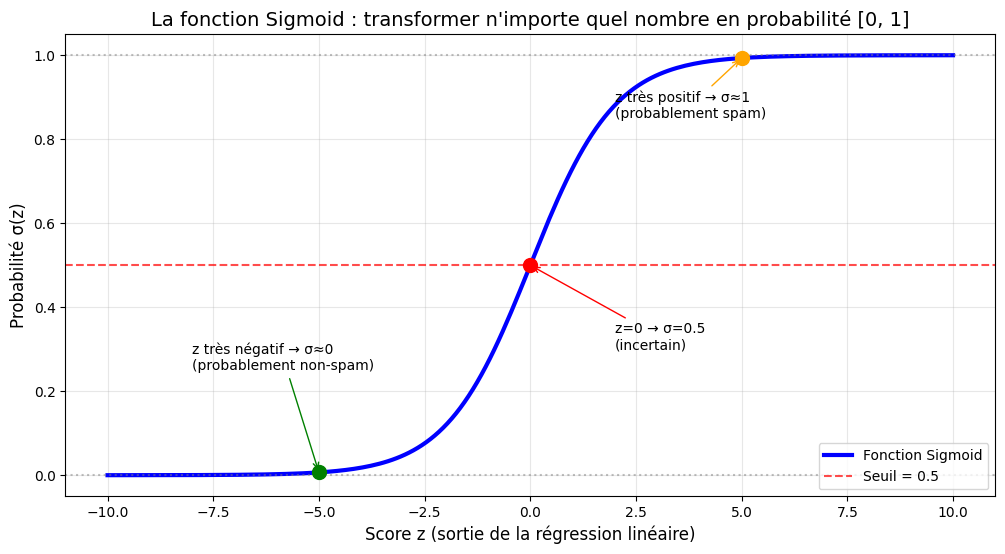

In [4]:
# Définir la fonction sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Visualiser
z = np.linspace(-10, 10, 200)
s = sigmoid(z)

plt.figure(figsize=(12, 6))
plt.plot(z, s, 'b-', linewidth=3, label='Fonction Sigmoid')

# Annotations
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Seuil = 0.5')
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
plt.axhline(y=1, color='gray', linestyle=':', alpha=0.5)

# Points remarquables
plt.scatter([0], [0.5], s=100, c='red', zorder=5)
plt.annotate('z=0 → σ=0.5\n(incertain)', xy=(0, 0.5), xytext=(2, 0.3),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))

plt.scatter([-5], [sigmoid(-5)], s=100, c='green', zorder=5)
plt.annotate('z très négatif → σ≈0\n(probablement non-spam)', 
             xy=(-5, sigmoid(-5)), xytext=(-8, 0.25),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='green'))

plt.scatter([5], [sigmoid(5)], s=100, c='orange', zorder=5)
plt.annotate('z très positif → σ≈1\n(probablement spam)', 
             xy=(5, sigmoid(5)), xytext=(2, 0.85),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='orange'))

plt.xlabel('Score z (sortie de la régression linéaire)', fontsize=12)
plt.ylabel('Probabilité σ(z)', fontsize=12)
plt.title('La fonction Sigmoid : transformer n\'importe quel nombre en probabilité [0, 1]', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

### Analysons cette courbe ensemble

Prenons le temps de comprendre ce que nous voyons sur ce graphique :

**La forme caractéristique en "S"**

Vous avez probablement deviné correctement ! La courbe a bien une forme de S (c'est pourquoi on l'appelle "sigmoïde", du grec *sigma*). Cette forme n'est pas un hasard — elle correspond exactement à ce dont nous avions besoin.

**Les trois zones clés de la courbe :**

| Zone | Valeur de z | Probabilité σ(z) | Ce que ça signifie | Point sur le graphique |
|------|-------------|------------------|-------------------|----------------------|
| **Gauche** | z < -2 | Proche de 0 (< 12%) | "Le modèle est confiant : probablement PAS un spam" | Point vert |
| **Centre** | -2 < z < 2 | Entre 12% et 88% | "Le modèle hésite, zone d'incertitude" | Zone de transition |
| **Droite** | z > 2 | Proche de 1 (> 88%) | "Le modèle est confiant : probablement un spam" | Point orange |

**Le point rouge central (z = 0)**

Quand z = 0, la sigmoid retourne exactement **0.5** (50%). C'est le point d'incertitude maximale — le modèle n'a aucune raison de pencher d'un côté ou de l'autre.

**Question :** Regardez la courbe. Que se passe-t-il entre z = 5 et z = 10 ? La probabilité change-t-elle beaucoup ?

*(Réponse attendue : Non, presque pas ! La courbe est "plate" dans cette zone. Une fois que le modèle est déjà "très sûr" (99%), plus d'évidence ne change pas grand-chose. C'est l'effet de saturation.)*

**La ligne rouge pointillée (seuil = 0.5)**

Cette ligne représente le **seuil de décision** par défaut :
- Au-dessus de cette ligne → on prédit "Spam"
- En-dessous de cette ligne → on prédit "Non-spam"

Nous reviendrons sur ce seuil plus tard — il peut être ajusté selon le contexte !

### La formule (pour les curieux)

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Vous n'avez pas besoin de mémoriser cette formule. Ce qui compte, c'est de comprendre le **comportement** : la sigmoid "écrase" n'importe quel nombre vers l'intervalle [0, 1], avec cette belle forme en S.

### Comprendre la courbe en S

```
┌───────────────────────────────────────────────────────────────────┐
│                     LA FONCTION SIGMOID                           │
├───────────────────────────────────────────────────────────────────┤
│                                                                   │
│  Probabilité                                                      │
│    1.0 ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ▄▄▀▀▀▀▀▀▀▀▀▀          │
│                                           ▄▀                      │
│    0.8                                  ▄▀                        │
│                                       ▄▀                          │
│    0.6                              ▄▀                            │
│                                   ▄▀                              │
│    0.5 ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ●                                 │
│                               ▄▀   ↑ Seuil de décision            │
│    0.4                      ▄▀                                    │
│                           ▄▀                                      │
│    0.2                  ▄▀                                        │
│                       ▄▀                                          │
│    0.0 ▀▀▀▀▀▀▀▀▀▀▀▄▀ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─           │
│         ─────────────────────────────────────────▶               │
│       -10        -5         0         5         10    Score z    │
│                                                                   │
│   • z < 0 : probabilité < 50% → prédit "Non-spam"                │
│   • z > 0 : probabilité > 50% → prédit "Spam"                    │
│   • Plus |z| est grand, plus la prédiction est "certaine"        │
│                                                                   │
└───────────────────────────────────────────────────────────────────┘
```

### Régression logistique = Régression linéaire + Sigmoid

/var/folders/01/2dhhcg55665c5vbwq1ll5qlh0000gn/T/ipykernel_78446/1943503272.py:34: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/01/2dhhcg55665c5vbwq1ll5qlh0000gn/T/ipykernel_78446/1943503272.py:34: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/safae/.universal_kernel/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/safae/.universal_kernel/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


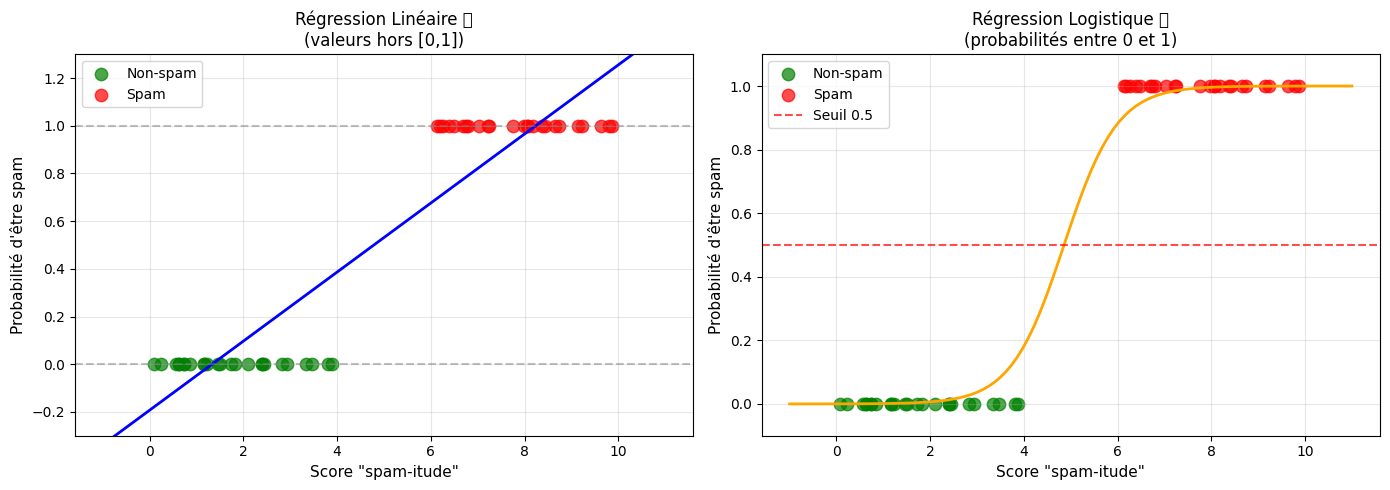

In [5]:
# Comparer régression linéaire vs logistique
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Données
for ax in axes:
    ax.scatter(score_spam[est_spam==0], est_spam[est_spam==0], 
               c='green', s=80, label='Non-spam', alpha=0.7)
    ax.scatter(score_spam[est_spam==1], est_spam[est_spam==1], 
               c='red', s=80, label='Spam', alpha=0.7)

# Régression linéaire (gauche)
axes[0].plot(x_line, y_pred_lineaire, 'b-', linewidth=2)
axes[0].set_title('Régression Linéaire ❌\n(valeurs hors [0,1])', fontsize=12)
axes[0].set_ylim(-0.3, 1.3)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5)

# Régression logistique (droite)
model_logistique = LogisticRegression()
model_logistique.fit(score_spam.reshape(-1, 1), est_spam)
y_pred_logistique = model_logistique.predict_proba(x_line.reshape(-1, 1))[:, 1]

axes[1].plot(x_line, y_pred_logistique, 'orange', linewidth=2)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Seuil 0.5')
axes[1].set_title('Régression Logistique ✅\n(probabilités entre 0 et 1)', fontsize=12)
axes[1].set_ylim(-0.1, 1.1)

for ax in axes:
    ax.set_xlabel('Score "spam-itude"', fontsize=11)
    ax.set_ylabel('Probabilité d\'être spam', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

````
┌─────────────────────────────────────────────────────────────────────────┐
│ 📖 DÉFINITION : Régression Logistique                                   │
│                                                                         │
│ La **régression logistique** est un algorithme de **classification**    │
│ qui prédit la probabilité qu'une observation appartienne à une classe.  │
│                                                                         │
│ Elle combine :                                                          │
│ 1. Une régression linéaire : z = w₁x₁ + w₂x₂ + ... + b                 │
│ 2. Une fonction sigmoid : P(classe=1) = 1 / (1 + e^(-z))               │
│                                                                         │
│ La sortie est une **probabilité** entre 0 et 1, interprétée comme la   │
│ confiance du modèle dans sa prédiction.                                 │
│                                                                         │
│ Malgré son nom, c'est un algorithme de **classification**, pas de      │
│ régression !                                                            │
└─────────────────────────────────────────────────────────────────────────┘
```

---

## 2.3 Construction du modèle

In [ ]:
import pandas as pd 

# 1. Transformation en DataFrame
df = pd.DataFrame({
    'score': score_spam,
    'cible': est_spam.astype(int) # .astype(int) pour avoir des 0/1 propres
})

# Mélanger les données (optionnel mais recommandé pour l'entraînement)
df = df.sample(frac=1).reset_index(drop=True)

display(df.head())

,score,cible
0,3.464705,0
1,8.430179,1
2,9.233589,1
3,6.185802,1
4,8.186841,1
5,3.879639,0
6,3.802857,0
7,6.260206,1
8,0.623978,0
9,8.736932,1


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# 2. Séparation des données
# X (caractéristiques) doit être une matrice (2D), y (cible) un vecteur
X = df[['score']]
y = df['cible']

# Division en ensemble d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# 3. Création et entraînement du modèle
model_logistique = LogisticRegression()
model_logistique.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# 4. Évaluation du modèle
y_pred = model_logistique.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Précision du modèle : {accuracy * 100}%")
# Le modèle affiche une précision de 100%. C'est attendu car les données sont parfaitement séparées (les non-spams sont entre 0 et 4, les spams entre 6 et 10).
print(f"Coefficient (pente) : {model_logistique.coef_[0][0]}")
print(f"Interception (biais) : {model_logistique.intercept_[0]}")

Précision du modèle : 100.0%
Coefficient (pente) : 1.6860911500171394
Interception (biais) : -8.254101766844414


/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


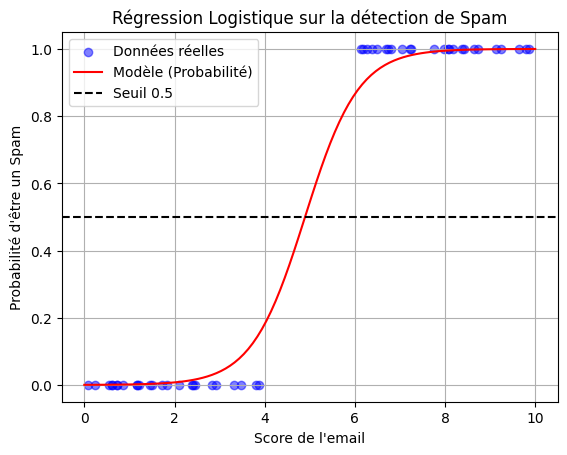

In [22]:
# 5. Visualisation de la courbe sigmoïde
plt.scatter(df['score'], df['cible'], color='blue', label='Données réelles', alpha=0.5)

# Générer des points pour tracer la fonction logistique
X_range = np.linspace(0, 10, 100).reshape(-1, 1)
y_prob = model_logistique.predict_proba(X_range)[:, 1] # Probabilité de la classe 1

plt.plot(X_range, y_prob, color='red', label='Modèle (Probabilité)')
plt.axhline(0.5, color='black', linestyle='--', label='Seuil 0.5')
plt.xlabel('Score de l\'email')
plt.ylabel('Probabilité d\'être un Spam')
plt.title('Régression Logistique sur la détection de Spam')
plt.legend()
plt.grid(True)
plt.savefig('logistic_regression_plot.png')

In [26]:
# import the metrics class
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[4, 0],
       [0, 6]])

NameError: name 'Text' is not defined

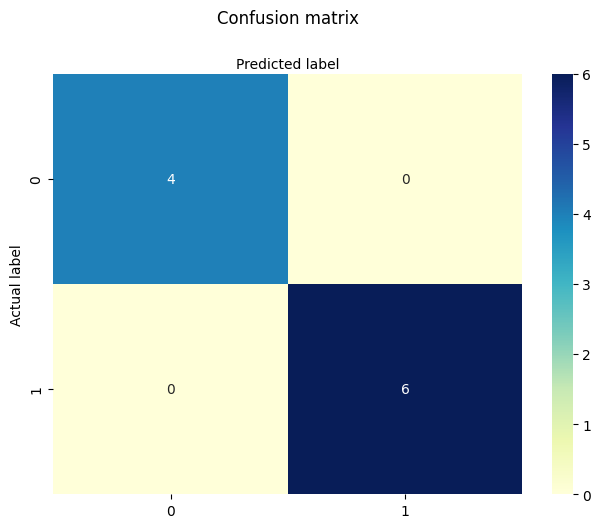

In [ ]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [29]:
from sklearn.metrics import classification_report
target_names = ['without diabetes', 'with diabetes']
print(classification_report(y_test, y_pred, target_names=target_names))

                  precision    recall  f1-score   support

without diabetes       1.00      1.00      1.00         4
   with diabetes       1.00      1.00      1.00         6

        accuracy                           1.00        10
       macro avg       1.00      1.00      1.00        10
    weighted avg       1.00      1.00      1.00        10



---

## 2.3 Seuil de Décision : Quand dit-on "Spam" ?

### De la probabilité à la décision

Nous avons maintenant un modèle qui prédit des **probabilités**. Par exemple :
- Email A : 73% de probabilité d'être spam
- Email B : 12% de probabilité d'être spam  
- Email C : 51% de probabilité d'être spam

**Question :** Comment transformez-vous ces probabilités en décisions concrètes ("Spam" ou "Non-spam") ?

*(Prenez un moment pour réfléchir... À partir de quel pourcentage diriez-vous "c'est un spam" ?)*

<details>
<summary>🔑 L'approche intuitive</summary>

La plupart des gens répondent : **"À partir de 50%"**.

C'est logique ! Si la probabilité est supérieure à 50%, c'est plus probable que ce soit un spam que l'inverse. Cette valeur de 50% s'appelle le **seuil de décision** (threshold en anglais).

</details>

### Le seuil par défaut : 0.5

Par défaut, la régression logistique utilise un seuil de **0.5** (50%) :

| Probabilité prédite | Comparaison au seuil | Décision |
|---------------------|---------------------|----------|
| 73% | 73% ≥ 50% ✓ | **Spam** |
| 12% | 12% < 50% ✗ | **Non-spam** |
| 51% | 51% ≥ 50% ✓ | **Spam** |
| 49% | 49% < 50% ✗ | **Non-spam** |

**Question :** Regardez le cas de l'email à 51% vs celui à 49%. Trouvez-vous normal qu'une différence de 2% change complètement la décision ?

*(Réponse attendue : C'est une bonne observation ! Les cas proches du seuil sont les plus "risqués" — le modèle n'est pas vraiment sûr. C'est pourquoi le choix du seuil est crucial.)*

Voyons ce que cela donne en pratique :

In [23]:
# Exemple : probabilités prédites
emails_test = np.array([2, 4, 5, 7, 8]).reshape(-1, 1)
probas = model_logistique.predict_proba(emails_test)[:, 1]

print("\nProbabilités d'être SPAM :")
print("═" * 50)
for score, proba in zip(emails_test.flatten(), probas):
    decision = "✉️ Non-spam" if proba < 0.5 else "🚫 SPAM"
    print(f"  Score {score} → Probabilité {proba:.1%} → {decision}")
print("═" * 50)


Probabilités d'être SPAM :
══════════════════════════════════════════════════
  Score 2 → Probabilité 0.8% → ✉️ Non-spam
  Score 4 → Probabilité 18.1% → ✉️ Non-spam
  Score 5 → Probabilité 54.4% → 🚫 SPAM
  Score 7 → Probabilité 97.2% → 🚫 SPAM
  Score 8 → Probabilité 99.5% → 🚫 SPAM
══════════════════════════════════════════════════


/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### Le dilemme du seuil : contexte business

**Question Socratique :** Imaginons deux situations :

1. **Gmail personnel** : Vous préférez que quelques spams passent plutôt que de rater un email important de votre famille
2. **Système bancaire anti-fraude** : Vous préférez bloquer quelques transactions légitimes plutôt que de laisser passer une fraude

Dans quel cas devrait-on **augmenter** le seuil ? Dans quel cas **diminuer** ?

*(Réponse attendue : Gmail → augmenter le seuil (moins de faux positifs). Banque → diminuer le seuil (moins de faux négatifs, quitte à avoir plus de faux positifs))*

/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


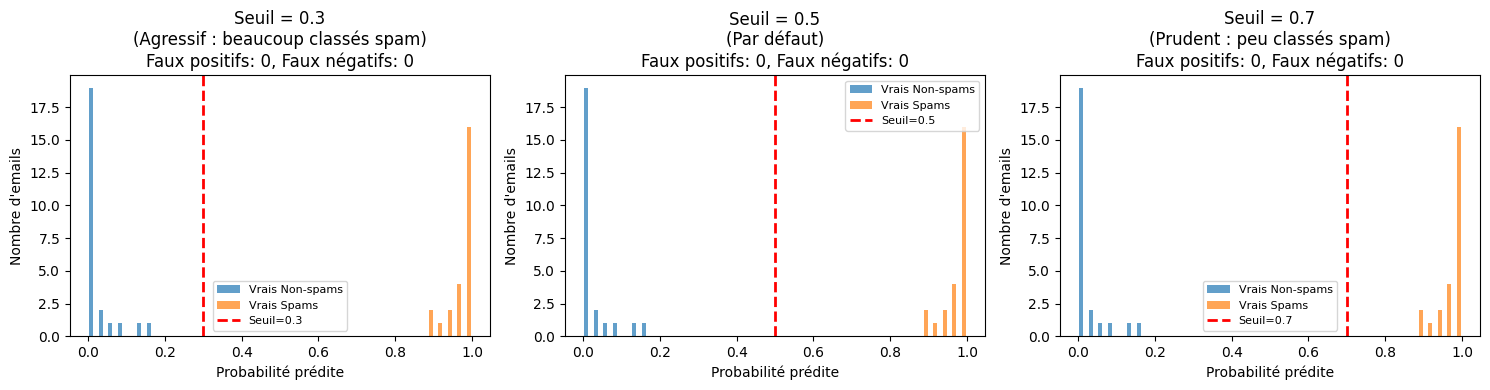

In [25]:
# Démontrer l'impact du seuil
def classifier_avec_seuil(probas, seuil):
    return (probas >= seuil).astype(int)

# Probabilités pour tous les emails
probas_all = model_logistique.predict_proba(score_spam.reshape(-1, 1))[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
seuils = [0.3, 0.5, 0.7]
titres = [
    "Seuil = 0.3\n(Agressif : beaucoup classés spam)",
    "Seuil = 0.5\n(Par défaut)",
    "Seuil = 0.7\n(Prudent : peu classés spam)"
]

for ax, seuil, titre in zip(axes, seuils, titres):
    predictions = classifier_avec_seuil(probas_all, seuil)
    
    # Compter les erreurs
    faux_positifs = np.sum((predictions == 1) & (est_spam == 0))
    faux_negatifs = np.sum((predictions == 0) & (est_spam == 1))
    
    # Plot
    ax.hist([probas_all[est_spam==0], probas_all[est_spam==1]], 
            bins=40, label=['Vrais Non-spams', 'Vrais Spams'], alpha=0.7)
    ax.axvline(x=seuil, color='red', linestyle='--', linewidth=2, label=f'Seuil={seuil}')
    ax.set_xlabel('Probabilité prédite')
    ax.set_ylabel('Nombre d\'emails')
    ax.set_title(f"{titre}\nFaux positifs: {faux_positifs}, Faux négatifs: {faux_negatifs}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Analysons ces trois graphiques

Prenons le temps de comprendre ce que nous montrent ces histogrammes :

**Comment lire chaque graphique :**
- **Barres bleues** : Les vrais Non-spams (emails légitimes). On voit où le modèle place leurs probabilités.
- **Barres oranges** : Les vrais Spams. On voit où le modèle place leurs probabilités.
- **Ligne rouge verticale** : Le seuil de décision. Tout ce qui est à droite = classé "Spam".

**Comparaison des trois seuils :**

| Seuil | Ce qui se passe | Faux Positifs | Faux Négatifs |
|-------|-----------------|---------------|---------------|
| **0.3 (agressif)** | On classe "Spam" dès 30% de probabilité. Beaucoup d'emails sont classés spam... y compris des légitimes ! | ⬆️ Augmente | ⬇️ Diminue |
| **0.5 (défaut)** | Équilibre classique : au-dessus de 50% = spam | Équilibré | Équilibré |
| **0.7 (prudent)** | On ne classe "Spam" qu'à partir de 70%. Beaucoup de spams passent... mais on ne rate presque aucun email légitime | ⬇️ Diminue | ⬆️ Augmente |

**L'observation clé :**

Regardez comment les barres bleues et oranges se chevauchent au milieu (autour de 0.4-0.6). C'est la **zone d'incertitude** : le modèle hésite entre spam et non-spam.

**Question :** En déplaçant le seuil, peut-on éliminer complètement les erreurs ?

*(Réponse attendue : Non ! Tant que les distributions se chevauchent, il y aura toujours un compromis. Baisser le seuil réduit les faux négatifs mais augmente les faux positifs, et vice-versa.)*

### Le compromis inévitable

C'est un principe fondamental en classification :

```
┌─────────────────────────────────────────────────────────────────────┐
│              LE COMPROMIS FAUX POSITIFS / FAUX NÉGATIFS             │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   Seuil BAS (ex: 0.3)           Seuil HAUT (ex: 0.7)               │
│   ─────────────────────         ─────────────────────               │
│   • Peu de FN (on rate          • Peu de FP (on ne classe          │
│     peu de vrais spams)           pas de légitimes en spam)        │
│   • Beaucoup de FP (on          • Beaucoup de FN (des spams        │
│     bloque des légitimes)         passent à travers)               │
│                                                                     │
│            ← ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ →                     │
│        Agressif                              Prudent                │
│                                                                     │
│   Le "bon" seuil dépend du CONTEXTE BUSINESS !                      │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

<details>
<summary>🤔 Question Socratique : Qu'est-ce qu'un faux positif vs un faux négatif dans le contexte du spam ?</summary>

### 🔑 Réponse

| Type d'erreur | Définition | Exemple spam |
|---------------|------------|---------------|
| **Faux Positif (FP)** | Prédire Spam alors que c'est Non-spam | Un email important de votre boss finit dans les spams 😱 |
| **Faux Négatif (FN)** | Prédire Non-spam alors que c'est Spam | Un email de phishing arrive dans votre boîte de réception 🎣 |

Le choix du seuil dépend de ce qui est le **plus grave** dans votre contexte :
- Si FP est grave → augmenter le seuil (être plus sûr avant de dire "Spam")
- Si FN est grave → diminuer le seuil (classer spam dès le moindre doute)

</details>

---

## 2.4 Classification Multiclasse

Jusqu'ici, on a prédit **2 classes** (spam/non-spam). Mais que faire si on a **3 classes ou plus** ?

Exemple : Classer un email comme **Personnel**, **Professionnel**, **Promotionnel**, ou **Spam**.

### Stratégie 1 : One-vs-Rest (OvR)

On entraîne **un modèle par classe** :
- Modèle 1 : Personnel vs (tout le reste)
- Modèle 2 : Professionnel vs (tout le reste)
- Modèle 3 : Promotionnel vs (tout le reste)
- Modèle 4 : Spam vs (tout le reste)

On prédit la classe dont le modèle donne la **plus haute probabilité**.

```
┌───────────────────────────────────────────────────────────────┐
│           ONE-VS-REST (pour 4 classes)                        │
├───────────────────────────────────────────────────────────────┤
│                                                               │
│  Email ──┬──▶ Modèle "Personnel?"      ──▶ P(Personnel)=0.1  │
│          │                                                    │
│          ├──▶ Modèle "Professionnel?"  ──▶ P(Pro)=0.7 ✓     │
│          │                                                    │
│          ├──▶ Modèle "Promotionnel?"   ──▶ P(Promo)=0.15     │
│          │                                                    │
│          └──▶ Modèle "Spam?"           ──▶ P(Spam)=0.05      │
│                                                               │
│  Prédiction finale : PROFESSIONNEL (probabilité la plus haute)│
└───────────────────────────────────────────────────────────────┘
```

In [10]:
# Exemple avec le dataset Iris (3 classes)
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Charger les données
iris = load_iris()
X_iris = iris.data
y_iris = iris.target  # 0, 1, ou 2

print("Classes :", iris.target_names)
print(f"Nombre d'observations : {len(y_iris)}")

Classes : ['setosa' 'versicolor' 'virginica']
Nombre d'observations : 150


In [11]:
# Split
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42
)

# Régression logistique multiclasse (automatique avec sklearn)
model_multi = LogisticRegression(max_iter=200)
model_multi.fit(X_train_iris, y_train_iris)

LogisticRegression(max_iter=200)

In [12]:
# Prédictions et probabilités
exemple = X_test_iris[0:1]
probas_exemple = model_multi.predict_proba(exemple)[0]

print("\n" + "═" * 50)
print("PRÉDICTION POUR UN EXEMPLE :")
print("═" * 50)
for classe, proba in zip(iris.target_names, probas_exemple):
    indicateur = " ✓" if proba == max(probas_exemple) else ""
    print(f"  P({classe:12s}) = {proba:.1%}{indicateur}")

print(f"\n→ Classe prédite : {iris.target_names[model_multi.predict(exemple)[0]]}")
print("═" * 50)


══════════════════════════════════════════════════
PRÉDICTION POUR UN EXEMPLE :
══════════════════════════════════════════════════
  P(setosa      ) = 0.4%
  P(versicolor  ) = 81.2% ✓
  P(virginica   ) = 18.4%

→ Classe prédite : versicolor
══════════════════════════════════════════════════


In [ ]:
# --- ÉTAPE 1 : PRÉPARATION DE LA DONNÉE ---

print("1️⃣ SÉLECTION DE LA DONNÉE")
# On prend la première ligne brute
fleur_brute = X_test_iris[0]
print(f"   Donnée brute (1D) : {fleur_brute}")
print(f"   Forme (shape)     : {fleur_brute.shape}")
print("-" * 40)

print("2️⃣ MISE EN FORME (RESHAPE)")
# Scikit-learn veut toujours un tableau 2D (Lignes, Colonnes)
fleur_prete = fleur_brute.reshape(1, -1)
print(f"   Donnée formatée (2D) : {fleur_prete}")
print(f"   Nouvelle forme       : {fleur_prete.shape}")
print("   (Note : On a maintenant 1 ligne et 4 colonnes)")
print("-" * 40)

In [ ]:
# --- ÉTAPE 2 : INTERROGATION DU MODÈLE ---

print("3️⃣ CALCUL DES PROBABILITÉS")
# Le modèle renvoie une liste de listes (car on pourrait lui donner plusieurs fleurs)
probas_brutes = model_multi.predict_proba(fleur_prete)
print(f"   Sortie brute du modèle : {probas_brutes}")
print("-" * 40)

print("4️⃣ EXTRACTION DES RÉSULTATS")
# On récupère la première (et seule) ligne de résultats
scores = probas_brutes[0]
print(f"   Liste des scores extraite : {scores}")
print("=" * 40)

In [ ]:
# --- ÉTAPE 3 : ANALYSE FINALE ---

print("\n📊 RAPPORT FINAL POUR L'UTILISATEUR :")
classes = iris.target_names # ['setosa', 'versicolor', 'virginica']

# On utilise zip pour coller le nom à la probabilité
for nom, score in zip(classes, scores):
    pourcentage = score * 100
    
    # Est-ce le score le plus élevé ?
    if score == max(scores):
        print(f"   👉 {nom.upper()} : {pourcentage:.2f}% (C'est la prédiction !)")
    else:
        print(f"      {nom} : {pourcentage:.2f}%")

print("\n" + "=" * 40)

1️⃣ SÉLECTION DE LA DONNÉE
   Donnée brute (1D) : [6.1 2.8 4.7 1.2]
   Forme (shape)     : (4,)
----------------------------------------
2️⃣ MISE EN FORME (RESHAPE)
   Donnée formatée (2D) : [[6.1 2.8 4.7 1.2]]
   Nouvelle forme       : (1, 4)
   (Note : On a maintenant 1 ligne et 4 colonnes)
----------------------------------------
3️⃣ CALCUL DES PROBABILITÉS
   Sortie brute du modèle : [[0.0040997  0.81234407 0.18355623]]
----------------------------------------
4️⃣ EXTRACTION DES RÉSULTATS
   Liste des scores extraite : [0.0040997  0.81234407 0.18355623]

📊 RAPPORT FINAL POUR L'UTILISATEUR :
      setosa : 0.41%
   👉 VERSICOLOR : 81.23% (C'est la prédiction !)
      virginica : 18.36%



In [14]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix

print("🚀 PRÉDICTION SUR TOUT LE JEU DE TEST")
print("=" * 50)

# --- 1. On donne TOUT X_test au modèle d'un coup ---
# Pas besoin de reshape ici car X_test est déjà en 2D (plusieurs lignes)
toutes_les_probas = model_multi.predict_proba(X_test_iris)
toutes_les_predictions = model_multi.predict(X_test_iris)

# --- 2. Vérification des dimensions (Le Debugging du Data Scientist) ---
print(f"Forme de X_test               : {X_test_iris.shape}  <- (Nbm fleurs, 4 mesures)")
print(f"Forme de toutes_les_probas    : {toutes_les_probas.shape} <- (Nbm fleurs, 3 probas)")
print(f"Forme de toutes_les_predictions : {toutes_les_predictions.shape}  <- (Nbm fleurs, 1 réponse)")
print("-" * 50)

# --- 3. Visualiser les résultats proprement (Façon "Excel") ---
# créer un DataFrame est le meilleur moyen de voir ce qui s'est passé
resultats = pd.DataFrame({
    'Vraie Classe': [iris.target_names[i] for i in y_test_iris],
    'Classe Prédite': [iris.target_names[i] for i in toutes_les_predictions],
    'Confiance (Proba Max)': [max(p) for p in toutes_les_probas]
})

# On ajoute une colonne pour voir si le modèle a eu bon
resultats['Correct ?'] = resultats['Vraie Classe'] == resultats['Classe Prédite']

print("\n👀 Aperçu des 5 premières prédictions :")
print(resultats.head())

print("\n" + "=" * 50)

# --- 4. Le Bilan Global ---
# Sur tout le test, on ne regarde plus ligne par ligne, on regarde la note globale
precision = accuracy_score(y_test_iris, toutes_les_predictions)
print(f"🏆 Précision globale (Accuracy) : {precision:.1%}")

# Combien d'erreurs au total ?
nb_erreurs = len(y_test_iris) - sum(resultats['Correct ?'])
print(f"❌ Nombre total d'erreurs      : {nb_erreurs} sur {len(y_test_iris)} fleurs")

🚀 PRÉDICTION SUR TOUT LE JEU DE TEST
Forme de X_test               : (45, 4)  <- (Nbm fleurs, 4 mesures)
Forme de toutes_les_probas    : (45, 3) <- (Nbm fleurs, 3 probas)
Forme de toutes_les_predictions : (45,)  <- (Nbm fleurs, 1 réponse)
--------------------------------------------------

👀 Aperçu des 5 premières prédictions :
  Vraie Classe Classe Prédite  Confiance (Proba Max)  Correct ?
0   versicolor     versicolor               0.812344       True
1       setosa         setosa               0.941955       True
2    virginica      virginica               0.997909       True
3   versicolor     versicolor               0.773252       True
4   versicolor     versicolor               0.751206       True

🏆 Précision globale (Accuracy) : 100.0%
❌ Nombre total d'erreurs      : 0 sur 45 fleurs



🔍 ANALYSE FINE DES ERREURS (MATRICE DE CONFUSION)
Matrice brute (difficile à lire pour un humain) :
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
--------------------------------------------------


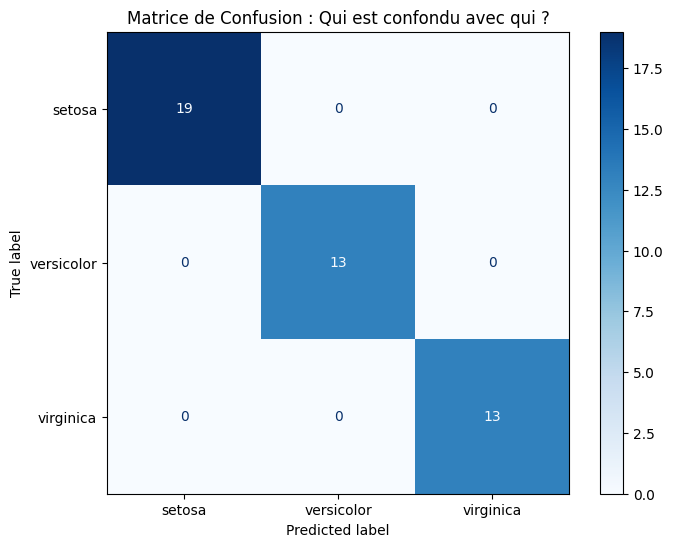

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\n🔍 ANALYSE FINE DES ERREURS (MATRICE DE CONFUSION)")
print("=" * 50)

# --- 1. Calcul de la matrice brute ---
# Lignes = La Vérité / Colonnes = La Prédiction du modèle
matrice = confusion_matrix(y_test_iris, toutes_les_predictions)

print("Matrice brute (difficile à lire pour un humain) :")
print(matrice)
print("-" * 50)

# --- 2. Visualisation Graphique (Le standard Pro) ---
# Scikit-learn a un outil intégré génial pour ça : ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=matrice, 
                              display_labels=iris.target_names) # On remet les vrais noms

# cmap='Blues' : Plus c'est foncé, plus il y a de monde
disp.plot(cmap='Blues', ax=ax)

plt.title("Matrice de Confusion : Qui est confondu avec qui ?")
plt.show()

### Stratégie 2 : Softmax (pour les curieux)

Au lieu de la sigmoid, on utilise la fonction **softmax** qui transforme un vecteur de scores en un vecteur de probabilités qui **somment à 1**.

C'est ce qu'utilise `LogisticRegression` de sklearn par défaut pour le multiclasse (paramètre `multi_class='multinomial'`).

---

## 🧪 Exercice Pratique : Détecter le Cancer du Sein

Un cas d'usage médical important : à partir de caractéristiques d'une tumeur, prédire si elle est **bénigne** ou **maligne**.

In [16]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Charger les données
cancer = load_breast_cancer()
X_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cancer = cancer.target  # 0 = maligne, 1 = bénigne

print(f"Dataset : {cancer.DESCR[:500]}...")
print(f"\nNombre d'observations : {len(y_cancer)}")
print(f"Classes : {cancer.target_names}")
print(f"Distribution : {np.bincount(y_cancer)}")

Dataset : .. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (...

Nombre d'observations : 569
Classes : ['malignant' 'benign']
Distribution : [212 357]


### Votre mission :

1. Séparez les données en train/test (80/20)
2. Normalisez les features (StandardScaler) - important pour la régression logistique !
3. Entraînez un modèle de régression logistique
4. Affichez l'accuracy sur le test set
5. Pour un nouveau patient, affichez la probabilité d'avoir une tumeur maligne

**Question bonus :** Dans ce contexte médical, vaut-il mieux minimiser les faux positifs ou les faux négatifs ?

In [17]:
# 🎯 À VOUS DE JOUER !

# Étape 1 : Split train/test
# X_train, X_test, y_train, y_test = ...

# Étape 2 : Normaliser (fit sur train, transform sur les deux)
# scaler = StandardScaler()
# X_train_scaled = ...
# X_test_scaled = ...

# Étape 3 : Entraîner
# model = LogisticRegression()
# model.fit(...)

# Étape 4 : Accuracy
# accuracy = model.score(...)

# Étape 5 : Probabilité pour le premier patient du test set
# probas = model.predict_proba(...)

## 🔑 Réponse à l'exercice

In [18]:
# Solution

# Étape 1 : Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

# Étape 2 : Normaliser
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)  # fit + transform sur train
X_test_scaled = scaler.transform(X_test_c)         # seulement transform sur test !

# Étape 3 : Entraîner
model_cancer = LogisticRegression(max_iter=1000)
model_cancer.fit(X_train_scaled, y_train_c)

# Étape 4 : Accuracy
accuracy = model_cancer.score(X_test_scaled, y_test_c)
print(f"\n✅ Accuracy sur le test set : {accuracy:.1%}")

# Étape 5 : Probabilité pour un patient
patient = X_test_scaled[0:1]
proba_maligne = model_cancer.predict_proba(patient)[0, 0]  # classe 0 = maligne
proba_benigne = model_cancer.predict_proba(patient)[0, 1]  # classe 1 = bénigne

print(f"\n🏥 Pour le premier patient du test set :")
print(f"   P(tumeur maligne)  = {proba_maligne:.1%}")
print(f"   P(tumeur bénigne)  = {proba_benigne:.1%}")
print(f"   → Diagnostic prédit : {'MALIGNE ⚠️' if proba_maligne > 0.5 else 'Bénigne ✓'}")
#print(f"   → Vrai diagnostic   : {'MALIGNE' if y_test_c.loc[0] == 0 else 'Bénigne'}")


✅ Accuracy sur le test set : 97.4%

🏥 Pour le premier patient du test set :
   P(tumeur maligne)  = 11.4%
   P(tumeur bénigne)  = 88.6%
   → Diagnostic prédit : Bénigne ✓


/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/safae/.universal_kernel/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise 

<details>
<summary>🤔 Question Bonus : Faux positifs vs faux négatifs en médecine ?</summary>

### 🔑 Réponse

Dans le contexte du cancer :

- **Faux Positif** : Dire "maligne" alors que c'est bénigne → Patient stressé, examens supplémentaires, mais pas de danger mortel
- **Faux Négatif** : Dire "bénigne" alors que c'est maligne → **DANGER** : le cancer n'est pas traité et peut progresser

**Conclusion** : En médecine, on veut **minimiser les faux négatifs** (ne pas rater un vrai cas). On préfère des faux positifs (surdiagnostic) que de passer à côté d'un cancer.

→ On pourrait **baisser le seuil** à 0.3 au lieu de 0.5 : dès 30% de probabilité de malignité, on fait des examens complémentaires.

</details>

---

## 📚 Récapitulatif

### Ce que vous avez appris :

1. **Problème** : La régression linéaire ne convient pas pour la classification (valeurs hors [0,1])
2. **Solution** : La fonction sigmoid transforme tout score en probabilité [0,1]
3. **Équation** : P(classe=1) = sigmoid(w₁x₁ + w₂x₂ + ... + b)
4. **Seuil** : Par défaut 0.5, mais ajustable selon le contexte business
5. **Multiclasse** : One-vs-Rest ou Softmax

### Code essentiel :

```python
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

# Prédire la classe
predictions = model.predict(X_test)

# Prédire les probabilités
probas = model.predict_proba(X_test)  # Colonnes = [P(classe0), P(classe1)]

# Prédire avec un seuil personnalisé
seuil = 0.3
predictions_custom = (model.predict_proba(X_test)[:, 1] >= seuil).astype(int)
```

### Prochaine partie : Arbres de Décision & Random Forest

Les modèles linéaires (régression linéaire et logistique) fonctionnent bien quand la relation est... linéaire ! Mais que faire quand ce n'est pas le cas ? Les **arbres de décision** offrent une approche totalement différente et très intuitive.

---

## 🤔 Réflexion Métacognitive

Avant de passer à la suite :

1. Pouvez-vous expliquer la différence entre régression linéaire et régression logistique à un non-technicien ?
2. Dans quel contexte ajusteriez-vous le seuil de décision ?
3. La régression logistique fait-elle de la **régression** ou de la **classification** ?

---

**Sources :**
- [IEEE 2024 - Email Spam Detection Using Logistic Regression and Explainable AI](https://ieeexplore.ieee.org/abstract/document/11013300/)
- [Springer 2024 - Improving spam email classification using ensemble techniques](https://link.springer.com/article/10.1007/s10207-023-00756-1)
- [scikit-learn LogisticRegression Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)